# Dataset 2 — Multi-Day TEC Forecasting Workflow

| Target Day | Date | Event |
|---|---|---|
| 33 | 2 May 2024 | G3 storm |
| 37 | 6 May 2024 | G2 storm |
| 40 | 9 May 2024 | Quiet Day |
| 41 | 10 May 2024 | G5 storm |

All heavy logic lives under `src/`. This notebook only calls functions.

**Flow** (mirrors the single-file reference notebook):
1. Imports
2. Load Dataset 2 and sort it
3. Build matrix, train LSTM & Transformer once, then forecast each target day
   (using the previous day as input) and compute ionospheric delays
4. Plots (generated for every target day) — LSTM/Transformer loss curves,
   actual vs predicted (LSTM & Transformer), L1+L5 combined ionospheric delay
5. Event-threshold metrics (3 m / 8 m / 15 m) for LSTM & Transformer, L1 & L5,
   for every target day, plus a TEC-level RMSE/MAE summary table


---
### Imports

In [1]:
import torch
import numpy as np
import pandas as pd

from src.preprocessing.sort_tec_data import build_sorted_dataset
from src.preprocessing.dataset import prepare_dataset
from src.configs.config import (
    BASE_DIR_2, OUTPUT_DIR_2, PLOTS_DIR_2, GENERATED_PLOTS_DIR,
    F_L1, F_L5,
    EVENT_THRESHOLD_PERCENTILE, DELAY_EVENT_THRESHOLDS_M,
    TARGET_DAYS,
    get_date_label,
)
from src.training.lstm_training import train_lstm
from src.training.transformer_training import train_transformer
from src.plots.loss_plots import plot_lstm_loss, plot_transformer_loss
from src.plots.prediction_plots import plot_lstm_prediction, plot_transformer_prediction
from src.plots.delay_plots import (
    plot_lstm_delay_l1_l5_combined,
    plot_transformer_delay_l1_l5_combined,
)
from src.utils.iono_delay import delay_metrics, tec_to_iono_delay, compute_all_delays
from src.utils.save_results import save_delay_csv
from src.utils.metrics import (
    rmse,
    pearson_correlation,
    probability_of_detection,
    critical_success_index,
    f1_score,
    false_alarm_ratio,
)

# This notebook always targets Dataset 2 — used for filenames, labels, and
# looking up real calendar dates via get_date_label(DATASET_NO, day).
DATASET_NO = 2


---
# Dataset 2 — Forecasting Workflow (Days {TARGET_DAYS})
---

### 1. Base Directory and Output Setup — Dataset 2

In [2]:
print(f"Base directory 2  : {BASE_DIR_2}")
print(f"Output directory 2: {OUTPUT_DIR_2}")
print(f"Target days        : {TARGET_DAYS}")

Base directory 2  : c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet2
Output directory 2: c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet2\sortedDataSet
Target days        : (33, 37, 40, 41)


### 2. Creating Sorted TEC Dataset — Dataset 2
```text
Process the raw per-satellite folders and create one sorted CSV per folder
containing the maximum TEC value for each minute.
Returns: Number of output CSV files written.
```

In [3]:
written_files_2 = build_sorted_dataset(2)

print("TEC data sorting completed — Dataset 2.")
print(f"Number of output CSV files written: {written_files_2}")
print(f"Saved sorted CSV files to: {OUTPUT_DIR_2}")

TEC data sorting completed — Dataset 2.
Number of output CSV files written: 41
Saved sorted CSV files to: c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet2\sortedDataSet


#### QUICK SANITY CHECK — Dataset 2
> Print first 6 lines of the first output file

In [4]:
sample_file_2 = OUTPUT_DIR_2 / "iisc0910_TECU_sorted.csv"
if sample_file_2.exists():
    with sample_file_2.open("r", newline="", encoding="utf-8") as f:
        for i, line in enumerate(f):
            print(line.strip())
            if i >= 5:
                break
else:
    print(f"Sample file not found: {sample_file_2}")

Time(UTC),TEC(TECU)
31-03-24 00:00,36.907657
31-03-24 00:01,38.230887
31-03-24 00:02,30.567575
31-03-24 00:03,31.386264
31-03-24 00:04,34.860934


### 3. Data Loading and Preprocessing — Dataset 2
```text
Loads sorted CSVs into a (days x minutes) numpy matrix,
builds supervised input/target pairs, and
normalises using training stats only.
```

In [5]:
X_train_2, y_train_2, X_val_2, y_val_2, stats_2, daily_matrix_2, daily_files_2 = prepare_dataset(2)

print(f"X_train : {X_train_2.shape}   y_train : {y_train_2.shape}")
print(f"X_val   : {X_val_2.shape}     y_val   : {y_val_2.shape}")
print(f"Norm stats : {stats_2}")

X_train : (29, 1440, 1)   y_train : (29, 1440, 1)
X_val   : (11, 1440, 1)     y_val   : (11, 1440, 1)
Norm stats : {'x_mean': 128.01817321777344, 'x_std': 59.78969956444336, 'y_mean': 128.05174255371094, 'y_std': 59.79975129173828}


### 4. LSTM Training Workflow — Dataset 2

> Dataset consists of 41 chronologically sorted TEC files.

```text
Training Set
------------
Input  : Days  1-29
Target : Days  2-30

Validation Set
--------------
Input  : Days 30-40
Target : Days 31-41

Forecast (per target day)
--------------------------
Input  : Day (target - 1)
Output : Day target
```

In [6]:
lstm_model_2, lstm_history_2 = train_lstm(X_train_2, y_train_2, X_val_2, y_val_2)

Epoch 1/50 — loss: 0.918997 — val_loss: 0.775285
Epoch 2/50 — loss: 0.763260 — val_loss: 0.546499
Epoch 3/50 — loss: 0.410011 — val_loss: 0.171813
Epoch 4/50 — loss: 0.250298 — val_loss: 0.197389
Epoch 5/50 — loss: 0.204431 — val_loss: 0.181901
Epoch 6/50 — loss: 0.189057 — val_loss: 0.168143
Epoch 7/50 — loss: 0.166629 — val_loss: 0.162503
Epoch 8/50 — loss: 0.156843 — val_loss: 0.155640
Epoch 9/50 — loss: 0.151543 — val_loss: 0.152629
Epoch 10/50 — loss: 0.148758 — val_loss: 0.151806
Epoch 11/50 — loss: 0.149446 — val_loss: 0.149968
Epoch 12/50 — loss: 0.144828 — val_loss: 0.154328
Epoch 13/50 — loss: 0.143949 — val_loss: 0.150096
Epoch 14/50 — loss: 0.146662 — val_loss: 0.153165
Epoch 15/50 — loss: 0.146448 — val_loss: 0.150410
Epoch 16/50 — loss: 0.145690 — val_loss: 0.151395
Epoch 17/50 — loss: 0.141061 — val_loss: 0.150866
Epoch 18/50 — loss: 0.141965 — val_loss: 0.150268
Epoch 19/50 — loss: 0.144823 — val_loss: 0.153367
Epoch 20/50 — loss: 0.142713 — val_loss: 0.150355
Epoch 21/

### 5. LSTM Loss and Validation Curve — Dataset 2

Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\loss_LSTM_dataset2.png


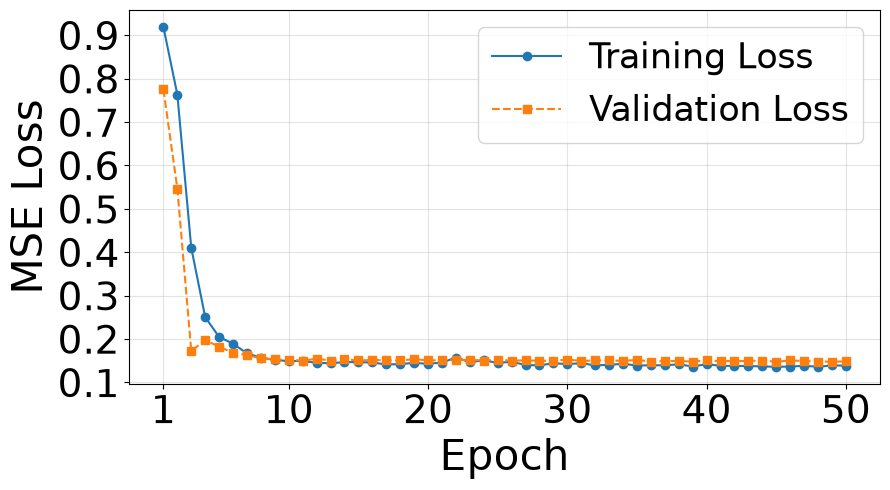

Final train loss : 0.138561
Final val   loss : 0.148053


In [7]:
plot_lstm_loss(lstm_history_2, dataset_label="dataset2", output_dir=str(PLOTS_DIR_2))

### 6. Transformer Training Workflow — Dataset 2

In [8]:
transformer_model_2, transformer_history_2 = train_transformer(X_train_2, y_train_2, X_val_2, y_val_2)

[Transformer] Training on: cpu
TECTransformerEncoder(
  (input_proj): Linear(in_features=1, out_features=64, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (output_proj): Linear(in_features=64, 

c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\src\models\transformer_model.py:101: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch   1/50 | loss: 2.432968 | val_loss: 2.315245 | lr: 1.14e-05
Epoch   2/50 | loss: 2.291738 | val_loss: 1.992822 | lr: 2.29e-05
Epoch   3/50 | loss: 2.096118 | val_loss: 1.616904 | lr: 3.43e-05
Epoch   4/50 | loss: 1.857865 | val_loss: 1.291522 | lr: 4.57e-05
Epoch   5/50 | loss: 1.545233 | val_loss: 1.015654 | lr: 5.71e-05
Epoch   6/50 | loss: 1.227040 | val_loss: 0.749816 | lr: 6.86e-05
Epoch   7/50 | loss: 0.975755 | val_loss: 0.546308 | lr: 8.00e-05
Epoch   8/50 | loss: 0.753493 | val_loss: 0.405130 | lr: 9.14e-05
Epoch   9/50 | loss: 0.610369 | val_loss: 0.299508 | lr: 1.00e-04
Epoch  10/50 | loss: 0.484393 | val_loss: 0.233210 | lr: 9.97e-05
Epoch  11/50 | loss: 0.409757 | val_loss: 0.196059 | lr: 9.90e-05
Epoch  12/50 | loss: 0.371981 | val_loss: 0.176357 | lr: 9.79e-05
Epoch  13/50 | loss: 0.330522 | val_loss: 0.166706 | lr: 9.64e-05
Epoch  14/50 | loss: 0.324777 | val_loss: 0.158955 | lr: 9.46e-05
Epoch  15/50 | loss: 0.293176 | val_loss: 0.155053 | lr: 9.24e-05
Epoch  16/

### 7. Transformer Loss and Validation Curve — Dataset 2

Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\loss_transformer_dataset2.png


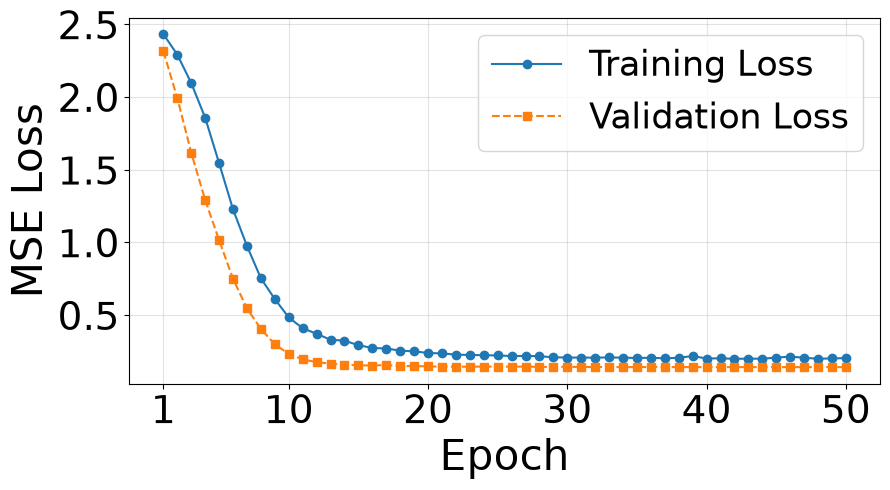

Final train loss : 0.204483
Final val   loss : 0.142177


In [9]:
plot_transformer_loss(transformer_history_2, dataset_label="dataset2", output_dir=str(PLOTS_DIR_2))

### 8. Forecast Every Target Day — Dataset 2

For each day in `TARGET_DAYS`, the previous day's TEC is fed in as input and
both trained models forecast the target day. Actual, LSTM-predicted, and
Transformer-predicted TEC (plus their L1 ionospheric delays) are collected
into `results_2[day]` for use by every plotting/metrics cell below.

In [10]:
x_mean_2, x_std_2 = stats_2["x_mean"], stats_2["x_std"]
y_mean_2, y_std_2 = stats_2["y_mean"], stats_2["y_std"]

device = next(lstm_model_2.parameters()).device
lstm_model_2.eval()
transformer_model_2.eval()

# results_2[day] = dict(actual=..., lstm_pred=..., trans_pred=..., date_label=...,
#                         iono_actual=..., iono_lstm=..., iono_trans=...)
results_2 = {}

for day in TARGET_DAYS:
    input_day_raw = daily_matrix_2[day - 2]   # day N-1 -> predicts day N
    actual_day    = daily_matrix_2[day - 1]

    input_norm = ((input_day_raw - x_mean_2) / x_std_2)[np.newaxis, ..., np.newaxis]
    src = torch.tensor(input_norm, dtype=torch.float32).to(device)

    with torch.no_grad():
        lstm_pred_norm  = lstm_model_2(src).squeeze().cpu().numpy()
        trans_pred_norm = transformer_model_2(src).squeeze().cpu().numpy()

    lstm_pred_day  = lstm_pred_norm  * y_std_2 + y_mean_2
    trans_pred_day = trans_pred_norm * y_std_2 + y_mean_2

    date_label_day = get_date_label(DATASET_NO, day)

    results_2[day] = dict(
        actual=actual_day,
        lstm_pred=lstm_pred_day,
        trans_pred=trans_pred_day,
        date_label=date_label_day,
        iono_actual=tec_to_iono_delay(actual_day),
        iono_lstm=tec_to_iono_delay(lstm_pred_day),
        iono_trans=tec_to_iono_delay(trans_pred_day),
    )

    print(f"Forecast day: {day}  ({date_label_day or 'date unknown'})  -- done")

Forecast day: 33  (02_May_2024_G3_Storm)  -- done
Forecast day: 37  (06_May_2024_G2_Storm)  -- done
Forecast day: 40  (09_May_2024)  -- done
Forecast day: 41  (10_May_2024_G5_Storm)  -- done


### 9. Actual vs Predicted TEC Plots — Dataset 2 (every target day)


Day 33  (02_May_2024_G3_Storm)
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\actual_vs_predicted_LSTM_02_May_2024_G3_Storm_dataset2.png


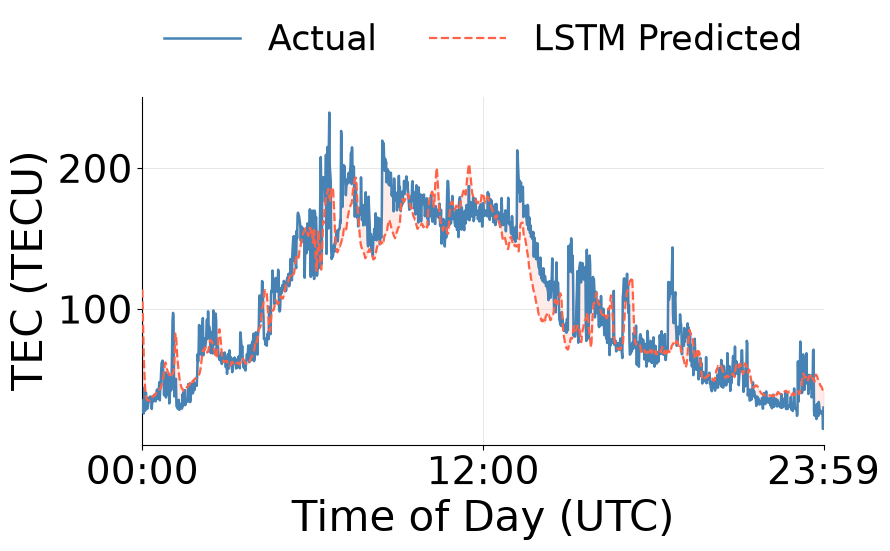

LSTM Day-33 RMSE : 19.9739 TECU
LSTM Day-33 MAE  : 14.6206 TECU
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\actual_vs_predicted_transformer_02_May_2024_G3_Storm_dataset2.png


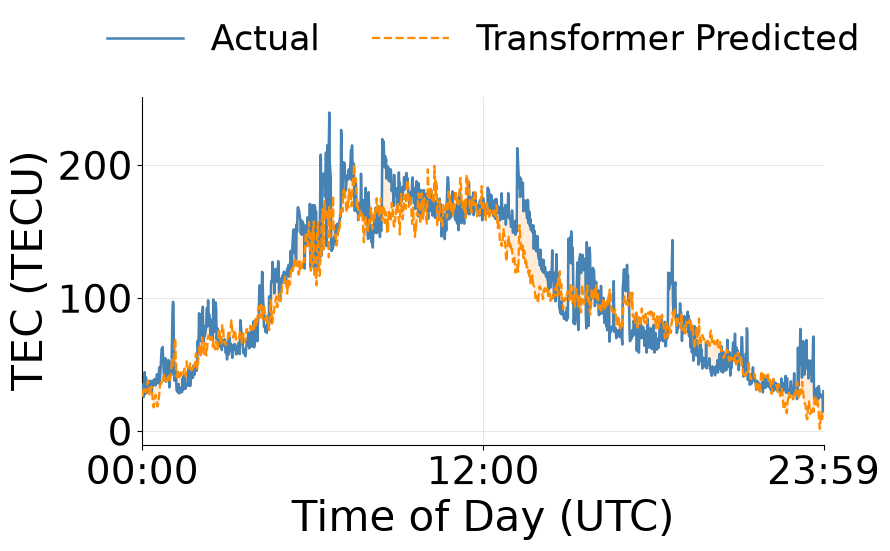

Transformer Day-33 RMSE : 19.8347 TECU
Transformer Day-33 MAE  : 15.0883 TECU

Day 37  (06_May_2024_G2_Storm)
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\actual_vs_predicted_LSTM_06_May_2024_G2_Storm_dataset2.png


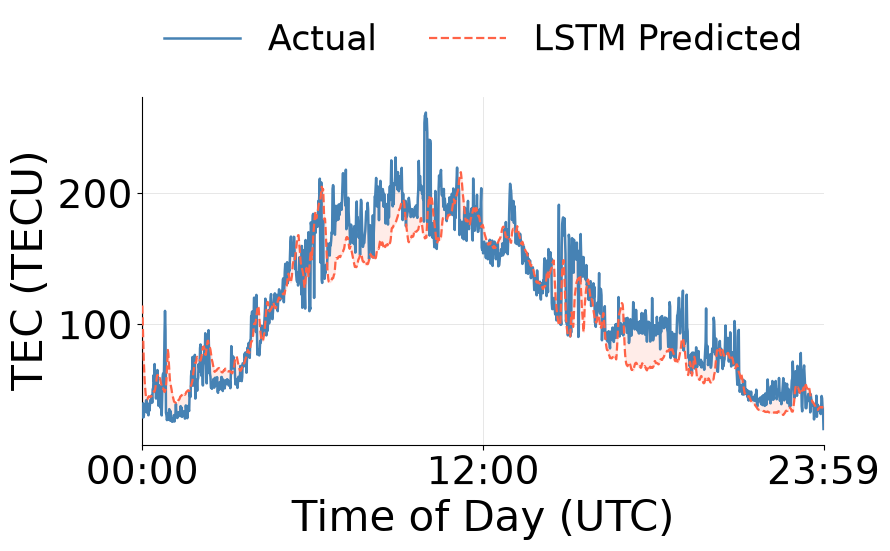

LSTM Day-37 RMSE : 22.2485 TECU
LSTM Day-37 MAE  : 16.8482 TECU
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\actual_vs_predicted_transformer_06_May_2024_G2_Storm_dataset2.png


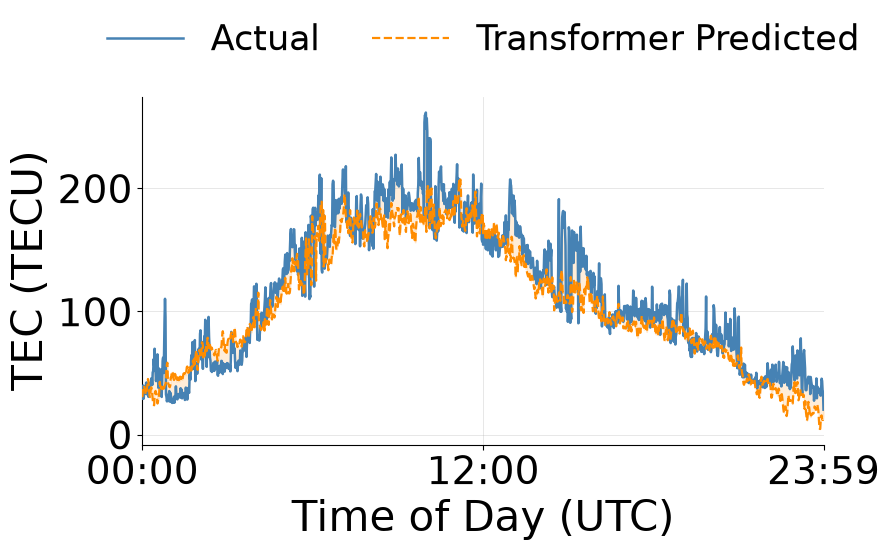

Transformer Day-37 RMSE : 20.7517 TECU
Transformer Day-37 MAE  : 16.1683 TECU

Day 40  (09_May_2024)
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\actual_vs_predicted_LSTM_09_May_2024_dataset2.png


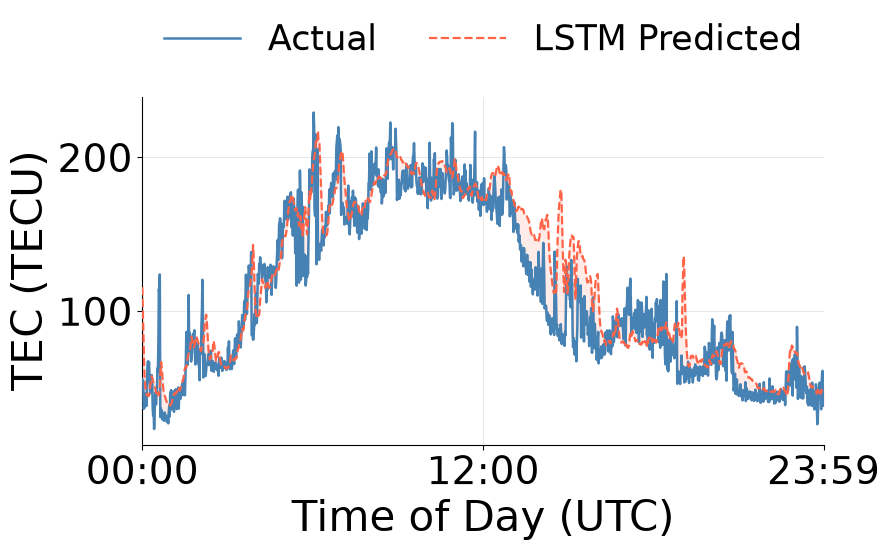

LSTM Day-40 RMSE : 20.8786 TECU
LSTM Day-40 MAE  : 14.8954 TECU
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\actual_vs_predicted_transformer_09_May_2024_dataset2.png


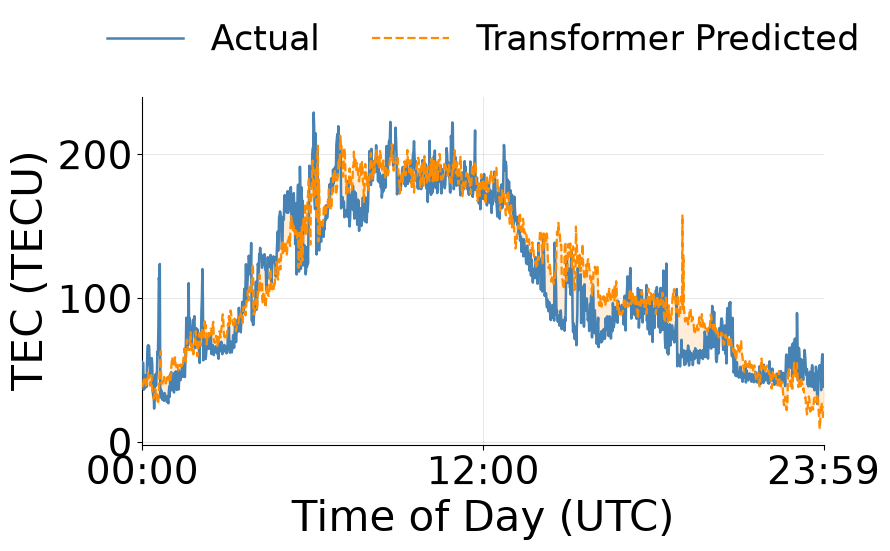

Transformer Day-40 RMSE : 19.8589 TECU
Transformer Day-40 MAE  : 15.4065 TECU

Day 41  (10_May_2024_G5_Storm)
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\actual_vs_predicted_LSTM_10_May_2024_G5_Storm_dataset2.png


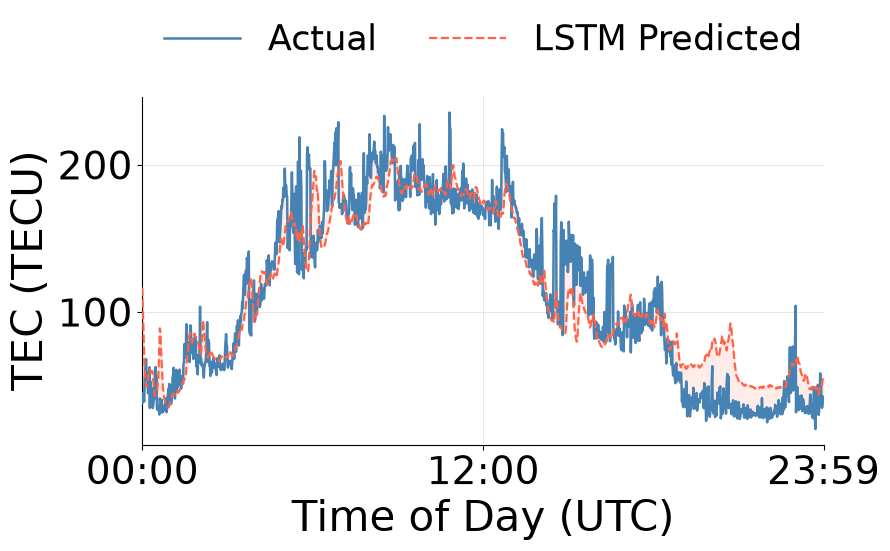

LSTM Day-41 RMSE : 21.7137 TECU
LSTM Day-41 MAE  : 16.7166 TECU
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\actual_vs_predicted_transformer_10_May_2024_G5_Storm_dataset2.png


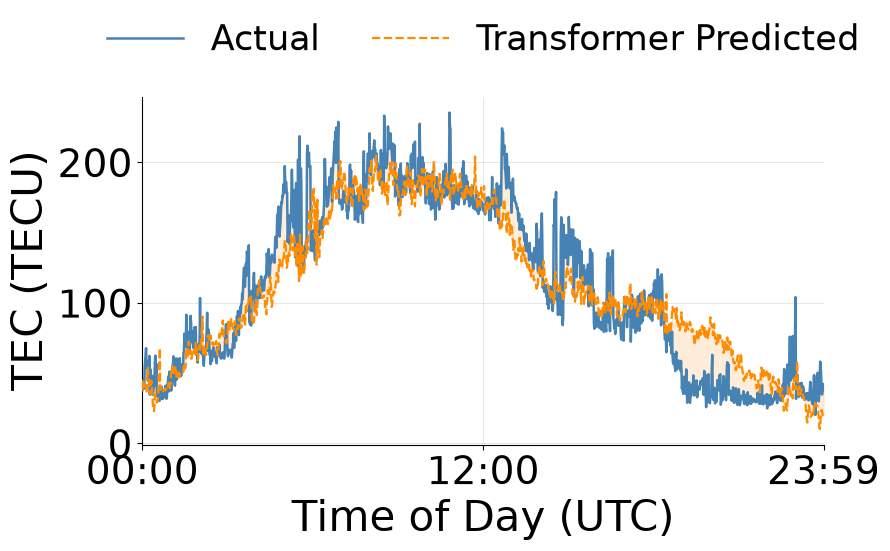

Transformer Day-41 RMSE : 22.3652 TECU
Transformer Day-41 MAE  : 17.5763 TECU


In [11]:
tec_metrics_2 = {}   # tec_metrics_2[day] = dict(lstm_rmse=, lstm_mae=, trans_rmse=, trans_mae=)

for day in TARGET_DAYS:
    r = results_2[day]
    print(f"\n{'=' * 70}\nDay {day}  ({r['date_label'] or 'date unknown'})\n{'=' * 70}")

    lstm_rmse_d, lstm_mae_d = plot_lstm_prediction(
        r["actual"], r["lstm_pred"], target_day=day, dataset_label=f"dataset{DATASET_NO}",
        date_label=r["date_label"], output_dir=str(PLOTS_DIR_2),
    )
    trans_rmse_d, trans_mae_d = plot_transformer_prediction(
        r["actual"], r["trans_pred"], target_day=day, dataset_label=f"dataset{DATASET_NO}",
        date_label=r["date_label"], output_dir=str(PLOTS_DIR_2),
    )

    tec_metrics_2[day] = dict(
        lstm_rmse=lstm_rmse_d, lstm_mae=lstm_mae_d,
        trans_rmse=trans_rmse_d, trans_mae=trans_mae_d,
    )

### 10. L1 + L5 Combined Ionospheric Delay Plots — Dataset 2 (every target day)


Day 33  (02_May_2024_G3_Storm) -- L1+L5 combined delay
LSTM L1 — RMSE: 3.24385 m   MAE: 2.37446 m
LSTM L5 — RMSE: 5.81710 m   MAE: 4.25805 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\ionospheric_delay_LSTM_L1_L5_combined_02_May_2024_G3_Storm_dataset2.png


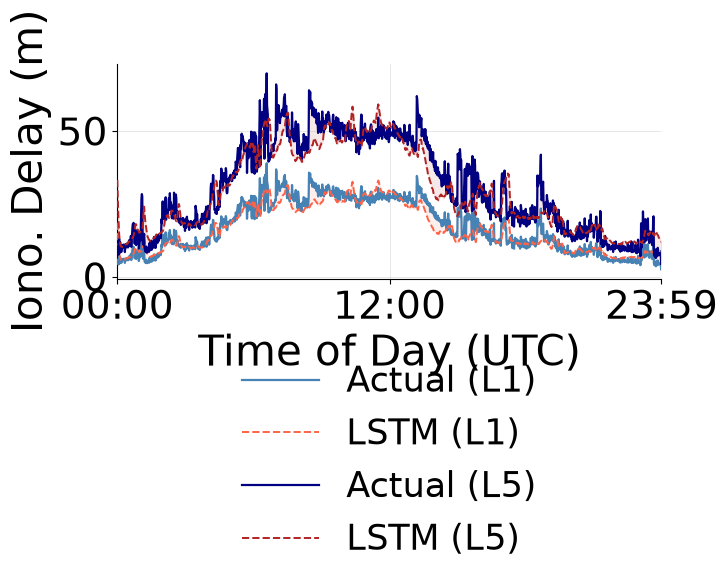

Transformer L1 — RMSE: 3.22125 m   MAE: 2.45042 m
Transformer L5 — RMSE: 5.77658 m   MAE: 4.39426 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\ionospheric_delay_transformer_L1_L5_combined_02_May_2024_G3_Storm_dataset2.png


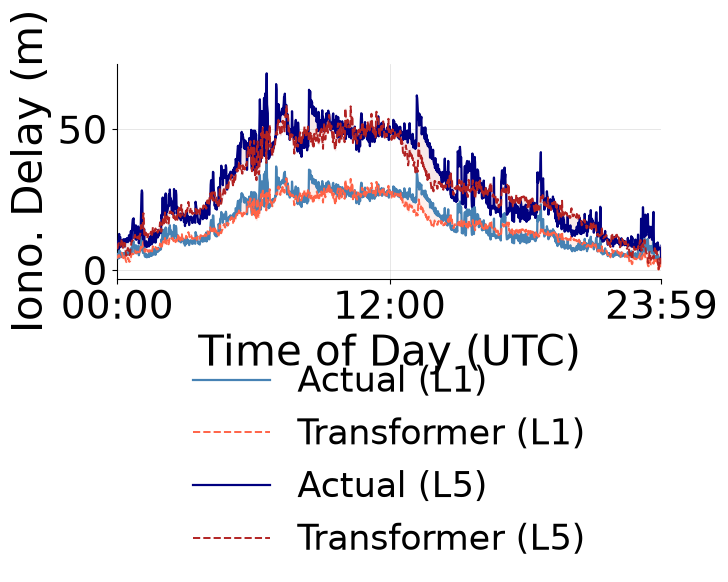


Day 37  (06_May_2024_G2_Storm) -- L1+L5 combined delay
LSTM L1 — RMSE: 3.61326 m   MAE: 2.73623 m
LSTM L5 — RMSE: 6.47955 m   MAE: 4.90679 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\ionospheric_delay_LSTM_L1_L5_combined_06_May_2024_G2_Storm_dataset2.png


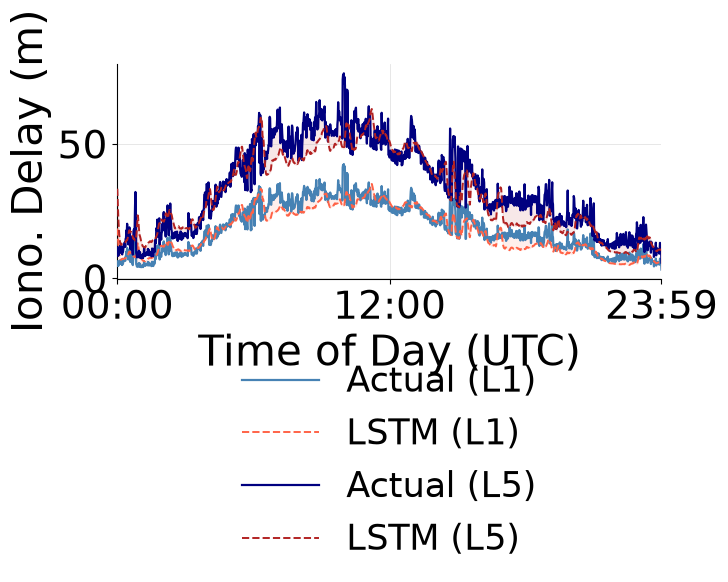

Transformer L1 — RMSE: 3.37017 m   MAE: 2.62580 m
Transformer L5 — RMSE: 6.04363 m   MAE: 4.70877 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\ionospheric_delay_transformer_L1_L5_combined_06_May_2024_G2_Storm_dataset2.png


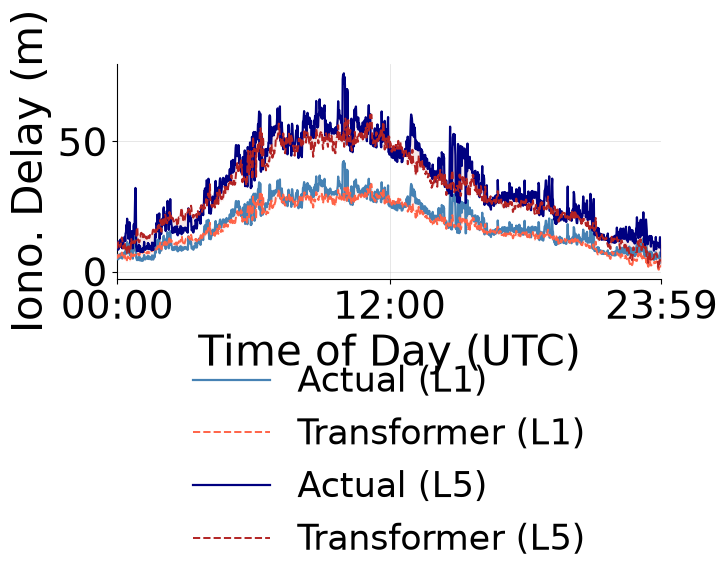


Day 40  (09_May_2024) -- L1+L5 combined delay
LSTM L1 — RMSE: 3.39078 m   MAE: 2.41908 m
LSTM L5 — RMSE: 6.08059 m   MAE: 4.33807 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\ionospheric_delay_LSTM_L1_L5_combined_09_May_2024_dataset2.png


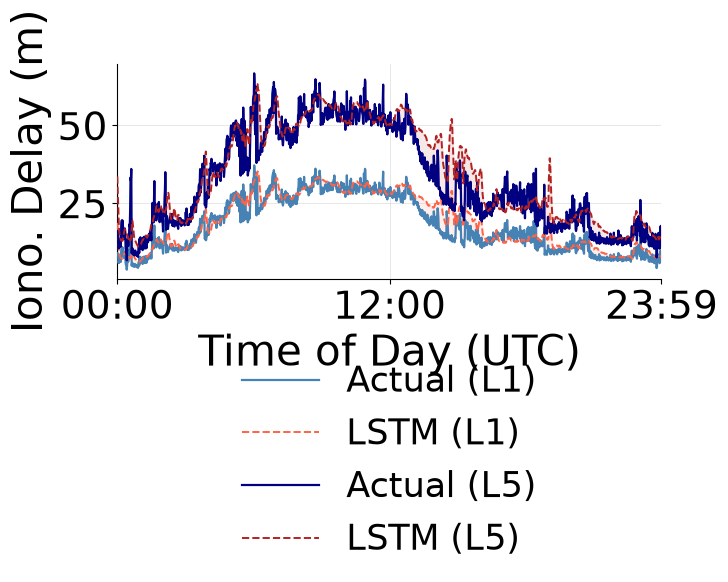

Transformer L1 — RMSE: 3.22517 m   MAE: 2.50209 m
Transformer L5 — RMSE: 5.78361 m   MAE: 4.48692 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\ionospheric_delay_transformer_L1_L5_combined_09_May_2024_dataset2.png


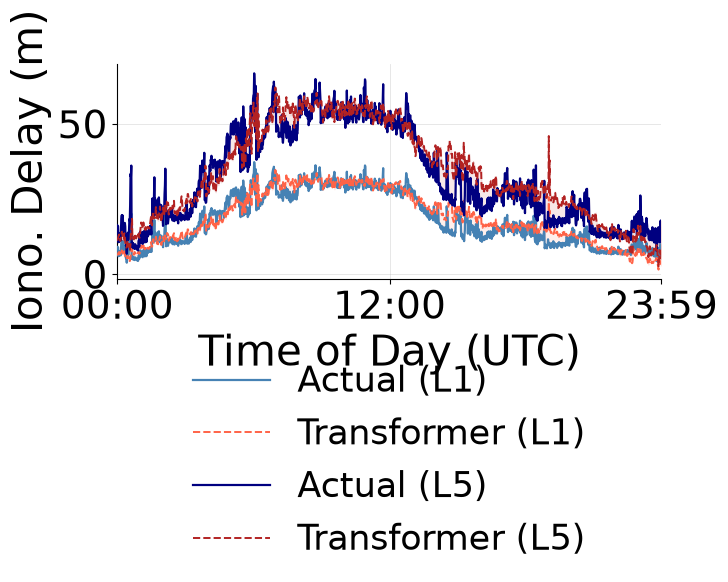


Day 41  (10_May_2024_G5_Storm) -- L1+L5 combined delay
LSTM L1 — RMSE: 3.52641 m   MAE: 2.71486 m
LSTM L5 — RMSE: 6.32381 m   MAE: 4.86848 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\ionospheric_delay_LSTM_L1_L5_combined_10_May_2024_G5_Storm_dataset2.png


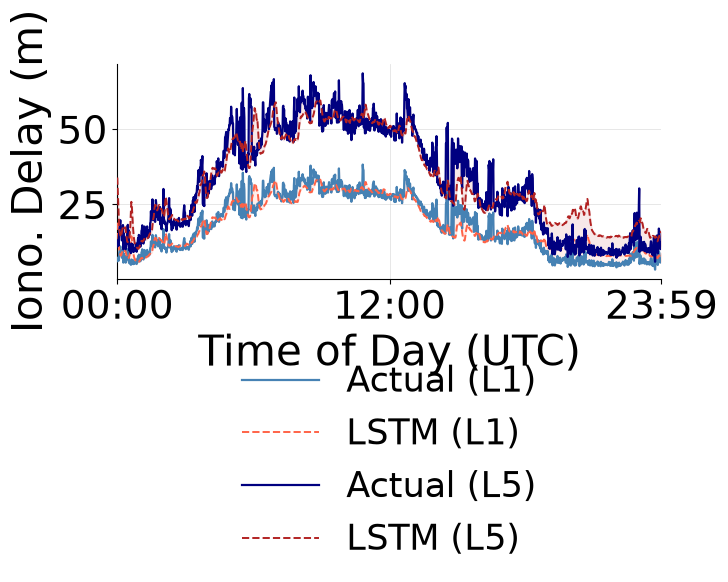

Transformer L1 — RMSE: 3.63222 m   MAE: 2.85447 m
Transformer L5 — RMSE: 6.51355 m   MAE: 5.11884 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset2_plots\ionospheric_delay_transformer_L1_L5_combined_10_May_2024_G5_Storm_dataset2.png


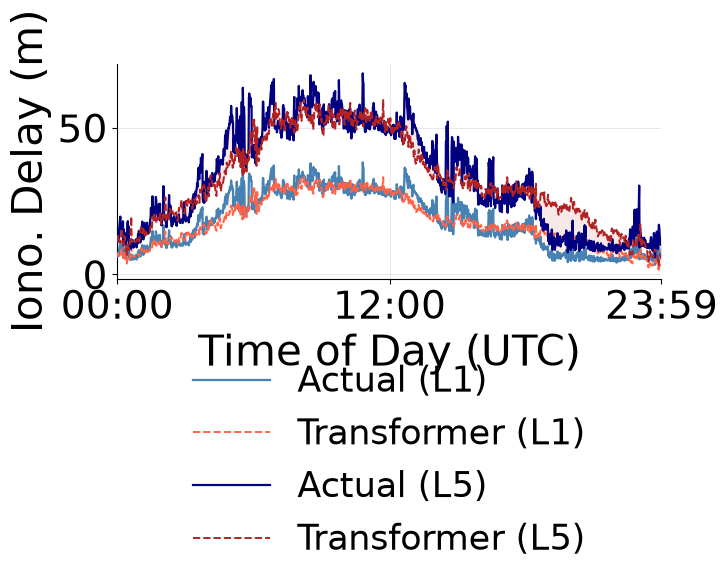

In [12]:
for day in TARGET_DAYS:
    r = results_2[day]
    print(f"\n{'=' * 70}\nDay {day}  ({r['date_label'] or 'date unknown'}) -- L1+L5 combined delay\n{'=' * 70}")

    plot_lstm_delay_l1_l5_combined(
        r["actual"], r["lstm_pred"], target_day=day, dataset_label=f"dataset{DATASET_NO}",
        date_label=r["date_label"], output_dir=str(PLOTS_DIR_2),
    )
    plot_transformer_delay_l1_l5_combined(
        r["actual"], r["trans_pred"], target_day=day, dataset_label=f"dataset{DATASET_NO}",
        date_label=r["date_label"], output_dir=str(PLOTS_DIR_2),
    )

### 11. Delay Error Metrics (L1, vertical) — Dataset 2 (every target day)

In [13]:
for day in TARGET_DAYS:
    r = results_2[day]
    print(f"\nIonospheric Delay Error (L1, vertical) — Day {day} ({r['date_label'] or 'date unknown'}) — Dataset {DATASET_NO}")
    print("=" * 70)
    delay_metrics("LSTM",        r["iono_lstm"],  r["iono_actual"])
    delay_metrics("Transformer", r["iono_trans"], r["iono_actual"])


Ionospheric Delay Error (L1, vertical) — Day 33 (02_May_2024_G3_Storm) — Dataset 2
LSTM             RMSE = 3.24385 m   MAE = 2.37446 m   Bias = -0.69795 m
Transformer      RMSE = 3.22125 m   MAE = 2.45042 m   Bias = -0.92568 m

Ionospheric Delay Error (L1, vertical) — Day 37 (06_May_2024_G2_Storm) — Dataset 2
LSTM             RMSE = 3.61326 m   MAE = 2.73623 m   Bias = -1.17889 m
Transformer      RMSE = 3.37017 m   MAE = 2.62580 m   Bias = -1.52288 m

Ionospheric Delay Error (L1, vertical) — Day 40 (09_May_2024) — Dataset 2
LSTM             RMSE = 3.39078 m   MAE = 2.41908 m   Bias = +1.14771 m
Transformer      RMSE = 3.22517 m   MAE = 2.50209 m   Bias = +0.72244 m

Ionospheric Delay Error (L1, vertical) — Day 41 (10_May_2024_G5_Storm) — Dataset 2
LSTM             RMSE = 3.52641 m   MAE = 2.71486 m   Bias = +0.10320 m
Transformer      RMSE = 3.63222 m   MAE = 2.85447 m   Bias = -0.26904 m


### 12. Save Forecast Output CSVs — Dataset 2 (every target day)

In [14]:
for day in TARGET_DAYS:
    r = results_2[day]
    save_delay_csv(
        r["actual"], r["lstm_pred"], r["trans_pred"],
        output_dir=OUTPUT_DIR_2,
        filename=f"day{day}_ionospheric_delay.csv",
    )

Delay table saved → c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet2\sortedDataSet\day33_ionospheric_delay.csv
Delay table saved → c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet2\sortedDataSet\day37_ionospheric_delay.csv
Delay table saved → c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet2\sortedDataSet\day40_ionospheric_delay.csv
Delay table saved → c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet2\sortedDataSet\day41_ionospheric_delay.csv


---
## Event-Threshold Metrics — Dataset 2

High-TEC threshold event detection at L1 and L5 ionospheric-delay thresholds
(3 m / 8 m / 15 m) for every target day, for both LSTM and Transformer.

In [15]:
freqs = {"L1": F_L1, "L5": F_L5}
event_rows_2 = []

for day in TARGET_DAYS:
    r = results_2[day]
    actual_day, lstm_pred_day, trans_pred_day = r["actual"], r["lstm_pred"], r["trans_pred"]

    for freq_label, freq_hz in freqs.items():
        iono_actual_f, iono_lstm_f, iono_trans_f = compute_all_delays(
            actual_day, lstm_pred_day, trans_pred_day, frequency=freq_hz
        )

        for model_name, pred_delay in (("LSTM", iono_lstm_f), ("Transformer", iono_trans_f)):
            overall_rmse = rmse(pred_delay, iono_actual_f)
            overall_corr = pearson_correlation(pred_delay, iono_actual_f)

            for thr in DELAY_EVENT_THRESHOLDS_M:
                pod = probability_of_detection(pred_delay, iono_actual_f, threshold=thr)
                csi = critical_success_index(pred_delay, iono_actual_f, threshold=thr)
                f1  = f1_score(pred_delay, iono_actual_f, threshold=thr)
                far = false_alarm_ratio(pred_delay, iono_actual_f, threshold=thr)

                event_rows_2.append({
                    "Day": day,
                    "Date": r["date_label"] or f"day{day}",
                    "Frequency": freq_label,
                    "Model": model_name,
                    "Threshold (m)": thr,
                    "Delay RMSE (m)": overall_rmse,
                    "Delay Correlation": overall_corr,
                    "POD": pod,
                    "CSI": csi,
                    "F1 Score": f1,
                    "FAR": far,
                })

event_metrics_table_2 = pd.DataFrame(event_rows_2).round(4)
print(f"Event-threshold metrics -- Dataset {DATASET_NO}, Days {TARGET_DAYS}")
print(event_metrics_table_2.to_string(index=False))

summary_csv_path_2 = GENERATED_PLOTS_DIR / f"event_threshold_metrics_dataset{DATASET_NO}.csv"
GENERATED_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
event_metrics_table_2.to_csv(summary_csv_path_2, index=False)
print(f"\nSaved event-threshold metrics table to: {summary_csv_path_2}")

event_metrics_table_2

Event-threshold metrics -- Dataset 2, Days (33, 37, 40, 41)
 Day                 Date Frequency       Model  Threshold (m)  Delay RMSE (m)  Delay Correlation    POD    CSI  F1 Score    FAR
  33 02_May_2024_G3_Storm        L1        LSTM            3.0          3.2439             0.9340 1.0000 0.9993    0.9997 0.0007
  33 02_May_2024_G3_Storm        L1        LSTM            8.0          3.2439             0.9340 0.9888 0.9119    0.9539 0.0786
  33 02_May_2024_G3_Storm        L1        LSTM           15.0          3.2439             0.9340 0.8821 0.8217    0.9021 0.0769
  33 02_May_2024_G3_Storm        L1 Transformer            3.0          3.2213             0.9369 0.9771 0.9771    0.9884 0.0000
  33 02_May_2024_G3_Storm        L1 Transformer            8.0          3.2213             0.9369 0.9647 0.9272    0.9622 0.0402
  33 02_May_2024_G3_Storm        L1 Transformer           15.0          3.2213             0.9369 0.9307 0.8614    0.9255 0.0796
  33 02_May_2024_G3_Storm        L5  

,Day,Date,Frequency,Model,Threshold (m),Delay RMSE (m),Delay Correlation,POD,CSI,F1 Score,FAR
0,33,02_May_2024_G3_Storm,L1,LSTM,3.0,3.2439,0.9340,1.0000,0.9993,0.9997,0.0007
1,33,02_May_2024_G3_Storm,L1,LSTM,8.0,3.2439,0.9340,0.9888,0.9119,0.9539,0.0786
2,33,02_May_2024_G3_Storm,L1,LSTM,15.0,3.2439,0.9340,0.8821,0.8217,0.9021,0.0769
3,33,02_May_2024_G3_Storm,L1,Transformer,3.0,3.2213,0.9369,0.9771,0.9771,0.9884,0.0000
4,33,02_May_2024_G3_Storm,L1,Transformer,8.0,3.2213,0.9369,0.9647,0.9272,0.9622,0.0402
5,33,02_May_2024_G3_Storm,L1,Transformer,15.0,3.2213,0.9369,0.9307,0.8614,0.9255,0.0796
6,33,02_May_2024_G3_Storm,L5,LSTM,3.0,5.8171,0.9340,1.0000,1.0000,1.0000,0.0000
7,33,02_May_2024_G3_Storm,L5,LSTM,8.0,5.8171,0.9340,1.0000,0.9882,0.9941,0.0118
8,33,02_May_2024_G3_Storm,L5,LSTM,15.0,5.8171,0.9340,0.9781,0.9095,0.9526,0.0716
9,33,02_May_2024_G3_Storm,L5,Transformer,3.0,5.7766,0.9369,0.9944,0.9944,0.9972,0.0000


### TEC-level summary (RMSE / MAE, TECU) — Dataset 2, all forecast days

In [16]:
tec_summary_rows_2 = []
for day in TARGET_DAYS:
    r = results_2[day]
    m = tec_metrics_2[day]
    tec_summary_rows_2.append({
        "Day": day,
        "Date": r["date_label"] or f"day{day}",
        "LSTM RMSE (TECU)": m["lstm_rmse"],
        "LSTM MAE (TECU)": m["lstm_mae"],
        "Transformer RMSE (TECU)": m["trans_rmse"],
        "Transformer MAE (TECU)": m["trans_mae"],
    })

tec_summary_table_2 = pd.DataFrame(tec_summary_rows_2).round(4)
print(tec_summary_table_2.to_string(index=False))

tec_summary_csv_path_2 = GENERATED_PLOTS_DIR / f"tec_forecast_summary_dataset{DATASET_NO}.csv"
tec_summary_table_2.to_csv(tec_summary_csv_path_2, index=False)
print(f"\nSaved TEC forecast summary to: {tec_summary_csv_path_2}")

tec_summary_table_2

 Day                 Date  LSTM RMSE (TECU)  LSTM MAE (TECU)  Transformer RMSE (TECU)  Transformer MAE (TECU)
  33 02_May_2024_G3_Storm           19.9739          14.6206                  19.8347                 15.0883
  37 06_May_2024_G2_Storm           22.2485          16.8482                  20.7517                 16.1683
  40          09_May_2024           20.8786          14.8954                  19.8589                 15.4065
  41 10_May_2024_G5_Storm           21.7137          16.7166                  22.3652                 17.5763

Saved TEC forecast summary to: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\tec_forecast_summary_dataset2.csv


,Day,Date,LSTM RMSE (TECU),LSTM MAE (TECU),Transformer RMSE (TECU),Transformer MAE (TECU)
0,33,02_May_2024_G3_Storm,19.9739,14.6206,19.8347,15.0883
1,37,06_May_2024_G2_Storm,22.2485,16.8482,20.7517,16.1683
2,40,09_May_2024,20.8786,14.8954,19.8589,15.4065
3,41,10_May_2024_G5_Storm,21.7137,16.7166,22.3652,17.5763
